# **Window Features Set Evaluation**

In [ ]:
#imports
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.linear_model import RidgeCV, LassoCV

from thesis_package.data.loaders import get_eligible_files, load_processed_dict, load_scores_df
from thesis_package.features.local_feature_extractor import WindowFeatureExtractor
from thesis_package.features.aggregation import aggregate_window_features
from thesis_package.analysis.analysis import loso_residual_analysis, get_top_correlations, permutation_significance_test
from thesis_package.training.evaluation import LOSOEvaluator, EvaluationConfig
from thesis_package.plotting.plotting import plot_correlation_matrix, plot_predicted_vs_true
from thesis_package.plotting.thesis_figures import plot_two_predicted_vs_true

In [2]:
# Load processed trajectory dataframes
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)
df_dict = load_processed_dict(eligible)

# load scores
df_scores = load_scores_df("../data/scores/merged_scores.csv")

# extract window features
extractor = WindowFeatureExtractor(hand="Right", window_sec=1.5, step_sec=0.5, log_transform=True, include_bimanual=True, exclude_idle=False)
df_window_features = extractor.extract_features(df_dict)

Extracting Right Features: 100%|██████████| 83/83 [01:37<00:00,  1.18s/it]


In [3]:
feature_cols = [col for col in df_window_features.columns if col not in ['video_id', 'window_start_frame', 'is_idle', 'total_path']]

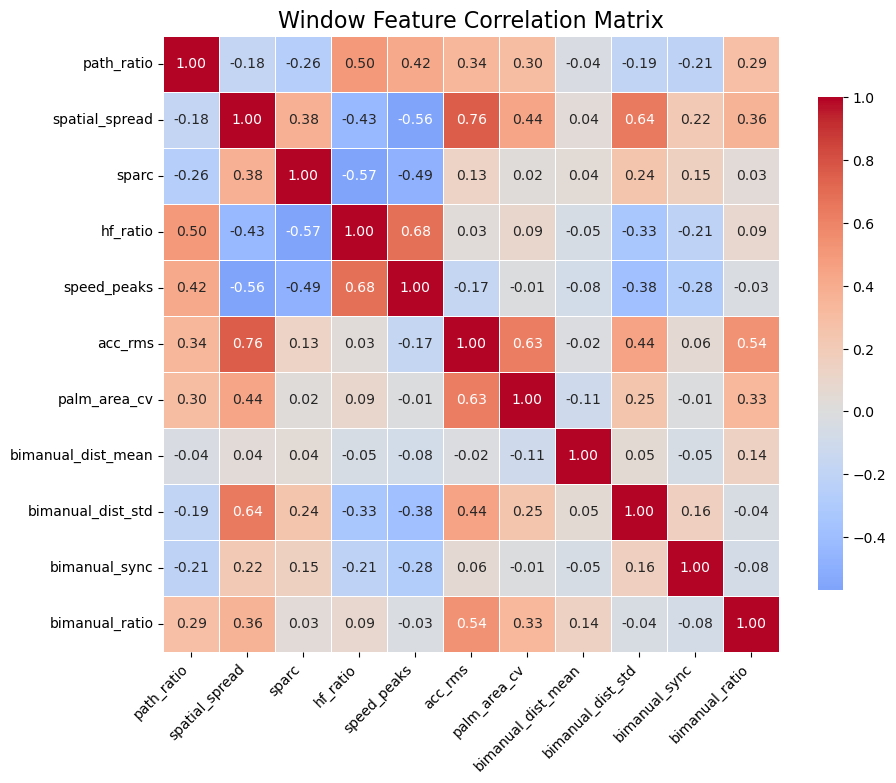

In [4]:
# feature intercorrelations
plot_correlation_matrix(df_window_features[feature_cols], title="Window Feature Correlation Matrix")

In [5]:
df_bimanual = df_window_features[df_window_features['bimanual_dist_mean'].notna()]
print(len(df_bimanual), "bimanual windows out of", len(df_window_features))

52956 bimanual windows out of 66805


In [6]:
# Idle is defined as < 1 px/frame at 30 fps and 1.5 sec windows => 45 pixels total path
df_window_features['is_idle'] = (df_window_features['total_path'] < 45).astype(int)
df_agg = aggregate_window_features(df_window_features, p=90, active_with_idle=False)

In [7]:

_, _ = get_top_correlations(df_agg.drop(columns=['video_id']), df_scores['QRS_Overal'].to_list())

Top 15 features by Pearson correlation:
path_ratio_std                 Pearson r = 0.4530, Spearman rho = 0.4620
speed_peaks_std                Pearson r = 0.4465, Spearman rho = 0.4677
path_ratio_p90                 Pearson r = 0.4363, Spearman rho = 0.4459
hf_ratio_p90                   Pearson r = 0.4170, Spearman rho = 0.4451
palm_area_cv_median            Pearson r = 0.4129, Spearman rho = 0.4167
spatial_spread_median          Pearson r = -0.3800, Spearman rho = -0.3791
path_ratio_median              Pearson r = 0.3697, Spearman rho = 0.3573
hf_ratio_std                   Pearson r = 0.3693, Spearman rho = 0.4182
speed_peaks_p90                Pearson r = 0.3677, Spearman rho = 0.3372
hf_ratio_median                Pearson r = 0.3645, Spearman rho = 0.3535
palm_area_cv_p10               Pearson r = 0.3056, Spearman rho = 0.3113
palm_area_cv_p90               Pearson r = 0.2849, Spearman rho = 0.3606
acc_rms_median                 Pearson r = 0.2663, Spearman rho = 0.2734
sparc_std

In [8]:
# load top feature df and combine with aggregated window features
df_pc1_features = pd.read_csv("../data/metrics/pc1_features.csv")
df_combined = pd.merge(df_pc1_features, df_agg, left_index=True, right_index=True)

In [9]:
# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_combined['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_combined.columns):
    df_combined = pd.concat([df_combined, df_case_onehot], axis=1)

In [10]:
pc1_features = [c for c in df_pc1_features.columns if '(R)' in c]
candidate_features = [col for col in df_combined.columns if col not in ['Participant Number', 'Case_Number', 'GRS_Total', 'QRS_Overal', 'video_id', 'Case_1', 'Case_2', 'Case_3', 'idle_prop', 'Velocity corr.'] + pc1_features]

#candidate_features.remove('velocity_ratio')
df_residuals_loso = loso_residual_analysis(df_combined, pc1_features, base_features=['Case_1', 'Case_2', 'Case_3'], candidate_features=candidate_features, top_n=1)
df_residuals_loso


,Feature,Partial_R2_mean,Partial_R2_std,Partial_R2_min,Resid_Corr_mean,Selection_Stability
36,spatial_spread_median,0.107770,0.014913,0.080682,-0.299781,1.0
10,bimanual_dist_std_p90,0.049442,0.011487,0.026749,-0.217456,0.0
2,acc_rms_p90,0.032815,0.009963,0.013376,-0.118423,0.0
16,bimanual_sync_median,0.032708,0.007801,0.014159,-0.173342,0.0
38,spatial_spread_p90,0.032667,0.009323,0.015186,-0.176412,0.0
11,bimanual_dist_std_std,0.025818,0.010108,0.005475,-0.155970,0.0
37,spatial_spread_p10,0.025589,0.007209,0.014580,-0.125733,0.0
15,bimanual_imbalance_std,0.024219,0.007747,0.012231,0.128684,0.0
3,acc_rms_std,0.023931,0.009293,0.004202,-0.141662,0.0
7,bimanual_dist_mean_std,0.020556,0.006603,0.012492,-0.144019,0.0


In [11]:
def print_performance(results, title):
    summary = results['summary']
    print(f"=== {title} Results ===")
    print(f"MAE: {summary['MAE']:.4f} ± {summary['MAE_STD']:.4f}")
    print(f"Spearman R: {summary['Spearman_R']:.4f} and R²: {summary['R2']:.4f}\n")

evaluator = LOSOEvaluator(EvaluationConfig(
    target_col="QRS_Overal",
    surgeon_col="Participant Number",
    video_col="video_id",
    device="cpu",
    seed=42,
))


In [12]:
ridge_results = evaluator.evaluate_tabular(
    df=df_combined,
    primary_features=pc1_features,
    extra_features=['Case_1', 'Case_2', 'Case_3', 'spatial_spread_median'],
    pca_components=[0],
    collect_weights=True,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    verbose=False
)

print_performance(ridge_results, "RidgeCV PC1 + casetypes + spatial spread median")
print(ridge_results['weights'])

=== RidgeCV PC1 + casetypes + spatial spread median Results ===
MAE: 4.9642 ± 3.8764
Spearman R: 0.7369 and R²: 0.5421

                 Feature  Average_Weight  Std_Weight
0                   bias       49.977080    0.306635
1                    PC1       -5.738634    0.156497
2                 Case_1       -1.838665    0.116873
3                 Case_2       -1.346705    0.171070
4                 Case_3        3.185369    0.150595
5  spatial_spread_median       -2.175920    0.151964


In [13]:
candidate_features = [c for c in candidate_features if 'bimanual' not in c] + ['Case_1', 'Case_2', 'Case_3']

lasso_results = evaluator.evaluate_tabular(
    df=df_combined,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=LassoCV(alphas=np.logspace(-1, 0.5, 30)),
    verbose=False
)

print_performance(lasso_results, "LassoCV PC1 + casetypes + all window features")
print(lasso_results['weights'])

=== LassoCV PC1 + casetypes + all window features Results ===
MAE: 5.2290 ± 4.2136
Spearman R: 0.7024 and R²: 0.4795

                  Feature  Average_Weight  Std_Weight
0                    bias       49.938586    0.308361
1                     PC1       -4.516782    0.196822
2   spatial_spread_median       -2.331197    0.207960
3      spatial_spread_std        0.000000    0.000000
4      spatial_spread_p90       -0.584651    0.300505
5      spatial_spread_p10        0.012713    0.067269
6          acc_rms_median        0.017378    0.064525
7             acc_rms_std        0.000000    0.000000
8             acc_rms_p90        0.006658    0.035228
9             acc_rms_p10        0.000000    0.000000
10        hf_ratio_median        0.000000    0.000000
11           hf_ratio_std        0.000000    0.000000
12           hf_ratio_p90        0.000000    0.000000
13           hf_ratio_p10        0.000000    0.000000
14      path_ratio_median        0.394137    0.272761
15         path_ra

# Test Shuffled Residuals

There is an imporvement with spatial spread median as an additional feature.    
But **is it significant** enough to include it in the model?    

It turns out **Not at all!**

Running 300 permutations...


100%|██████████| 300/300 [26:51<00:00,  5.37s/it]


--- Significance Results ---
Real Partial R2: 0.1078
Empirical p-value: 0.3000
Z-score vs Null: 0.42


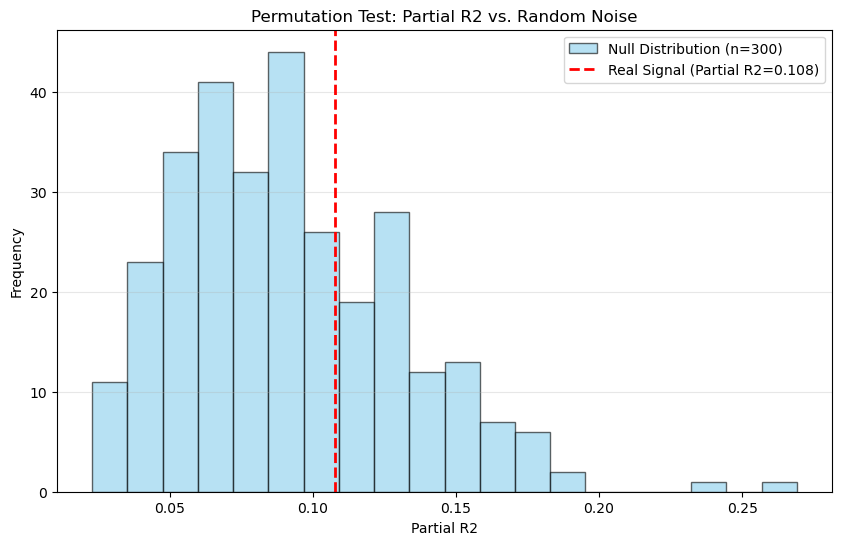

In [ ]:
real_signal = df_residuals_loso['Partial_R2_mean'].values[0]

# 2. Run the test
results = permutation_significance_test(
    df=df_combined,
    top_features_right=pc1_features,
    candidate_features=candidate_features,
    real_val=real_signal,
    extra_Features=['Case_1', 'Case_2', 'Case_3'],
    n_shuffles=300,
    show_plot=True
)

### Comparison With Mean Pooling + PC1

This was motivated by the observation in that PC1 + mean pooling of the global features performs so good in the attention ablation study.

=== RidgeCV PC1 + median of selected window features Results ===
MAE: 4.7175 ± 3.4858
Spearman R: 0.7795 and R²: 0.6029

                 Feature  Average_Weight  Std_Weight
0                   bias       49.938586    0.308361
1                    PC1       -4.779442    0.147139
2  spatial_spread_median       -2.893555    0.131335
3      path_ratio_median        2.447558    0.131956
4           sparc_median        2.792333    0.204680
5    palm_area_cv_median        2.553272    0.149033


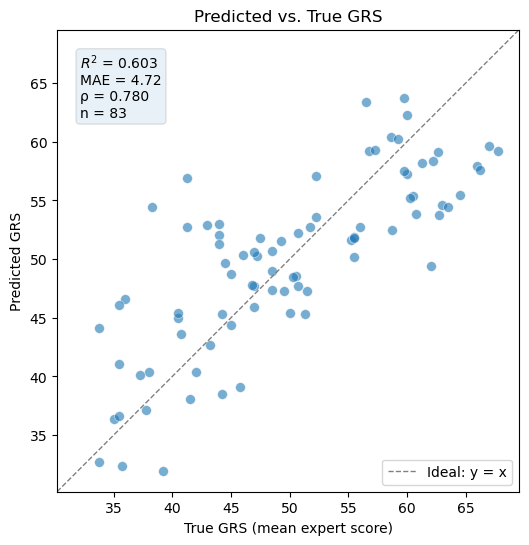

In [14]:
candidate_features = ['spatial_spread_median', 'path_ratio_median', 'sparc_median', 'palm_area_cv_median']

diagnostic_results = evaluator.evaluate_tabular(
    df=df_combined,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    verbose=False
)

print_performance(diagnostic_results, "RidgeCV PC1 + median of selected window features")
print(diagnostic_results['weights'])

_, _ = plot_predicted_vs_true(diagnostic_results['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)

=== RidgeCV selectedwindow features only Results ===
MAE: 6.2977 ± 3.8716
Spearman R: 0.6044 and R²: 0.3692

                 Feature  Average_Weight  Std_Weight
0                   bias       49.938586    0.308361
1  spatial_spread_median       -4.807297    0.185818
2      path_ratio_median        2.708884    0.196313
3           sparc_median        2.977808    0.245592
4    palm_area_cv_median        4.269021    0.207899


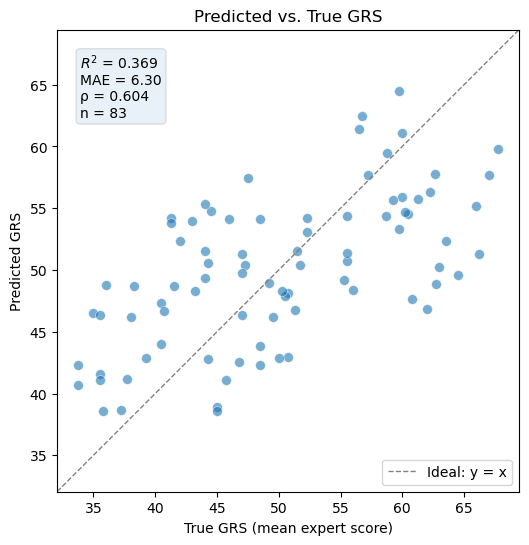

In [15]:
ridge_results = evaluator.evaluate_tabular(
    df=df_combined,
    primary_features=candidate_features,
    collect_weights=True,
    model=RidgeCV(alphas=np.logspace(-1, 0.5, 20)),
    verbose=False
)

print_performance(ridge_results, "RidgeCV selected window features only")
print(ridge_results['weights'])

_, _ = plot_predicted_vs_true(ridge_results['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)

=== PC1 Only Results ===
MAE: 5.3534 ± 4.1117
Spearman R: 0.6920 and R²: 0.4741

  Feature  Average_Weight  Std_Weight
0    bias       49.938586    0.308361
1     PC1       -6.612760    0.164767


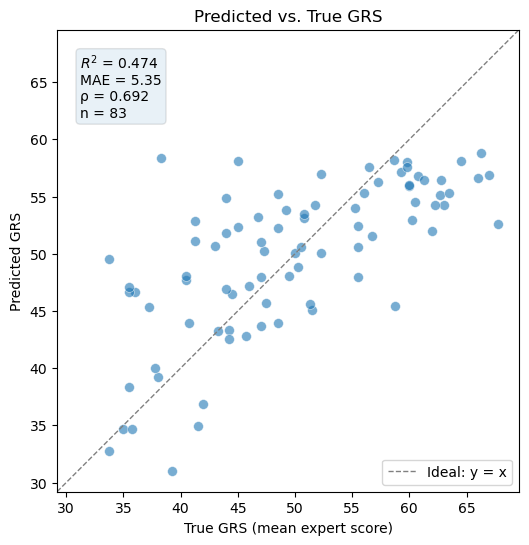

In [ ]:
from sklearn.linear_model import LinearRegression

candidate_features = []

pc1_only_results = evaluator.evaluate_tabular(
    df=df_combined,
    primary_features=pc1_features,
    extra_features=candidate_features,
    pca_components=[0],
    collect_weights=True,
    model=LinearRegression(),
    verbose=False
)

print_performance(pc1_only_results, "PC1 Only")
print(pc1_only_results['weights'])

_, _ = plot_predicted_vs_true(pc1_only_results['predictions'], 
                       show_group_labels=False, 
                       add_fit_line=False)

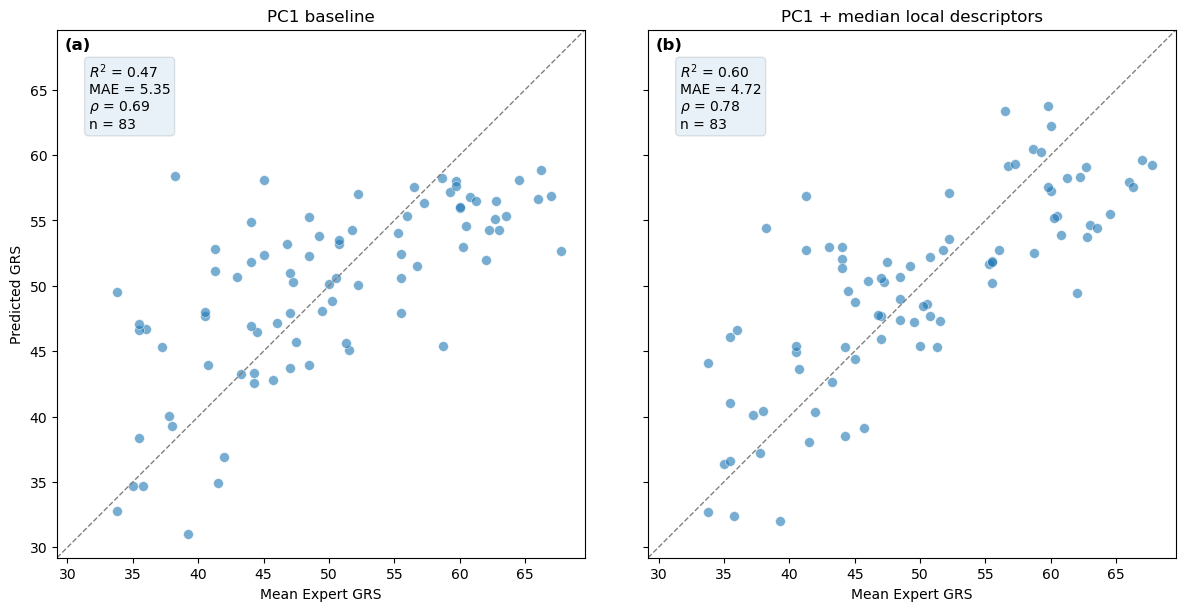

In [ ]:
# comparison figure for thesis - PC1 only vs PC1 + selected window features

fig, axes, metrics = plot_two_predicted_vs_true(
    df_left=pc1_only_results['predictions'],
    df_right=diagnostic_results['predictions'],
    true_col="True",
    pred_col="Pred",
    left_title="PC1 baseline",
    right_title="PC1 + median local descriptors",
    save_path="figures/predicted_vs_true_comparison.png",
    dpi=400,
    save_pdf=True,
)